# Overview of behavioral measures and magnitude comparison task parameters

In [1]:
import itertools
import os.path as op

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pingouin

from numrisk.behavior_general.measures_registry import load_all, PHENOTYPE_DIR

sns.set_context('notebook')

plot_folder = '/Users/mrenke/obsidian-wiki/thesis/plots'

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


## Cross-measure correlations (behavioral measures)

Spearman correlations between all behavioral measures collected for the DNumRisk sample: raw magjudge accuracy/RT, magnitude-comparison task parameters (psychometric model + PMC-RDM noise-dissociation model), standardized cognitive measures, and questionnaires. Demographic columns (age, group, gender), the risk task, and neural measures are excluded.

In [2]:
df, col_to_category = load_all()

# Raw magjudge task performance (not in the measures registry)
df_raw = pd.read_csv(op.join(PHENOTYPE_DIR, 'magjudge_raw_correct_rt.csv')).set_index('subject')
df_raw = df_raw.rename(columns={'correct': 'accuracy_magjudge', 'rt': 'rt_magjudge'})
df = df.join(df_raw, how='left')
col_to_category.update({c: 'behavioral_magjudge' for c in df_raw.columns})

behavioral_categories = ['behavioral_magjudge', 'behavioral_cognitive', 'behavioral_questionnaire']
corr_vars = [c for c, cat in col_to_category.items() if cat in behavioral_categories]

corr = df[corr_vars].corr(method='spearman')
exclude = {'intercept_magjudge', 'intercept_magjudge_abs'}  # whatever you don't want
corr_vars = [c for c in corr_vars if c not in exclude]
corr.shape

(20, 20)

In [3]:
# Readable variable names (matches terminology used in the thesis chapter text)
pretty_names = {
    'accuracy_magjudge': 'Raw: Accuracy',
    'rt_magjudge': 'Raw: Reaction time',
    'gamma_magjudge': 'Probit: slope (γ)',
    #'intercept_magjudge': 'Psychometric intercept',
    #'intercept_magjudge_abs': 'Psychometric intercept (abs.)',
    'n1_slope': 'Probit: number-range effect',
    'perceptual_noise_sd': 'PMC-RDM: Perceptual noise',
    'memory_noise_sd': 'PMC-RDM:  Memory noise',
    'a': 'PMC-RDM: Boundary separation (a)',
    't0': 'PMC-RDM: Non-decision time (t0)',
    'mean_iq': 'Mean IQ',
    'me': 'Visuospatial IQ (Matrizen)',
    'kn': 'Verbal IQ (Kategorien nennen)',
    'erfassungsspanne': 'Visuospatial WM (Corsi span)',
    'weber_transformed': 'Weber fraction (log)',
    'skill_score': 'Math skill (DEMAT)',
    'anx_mean': 'Math anxiety',
    'conf_mean': 'Math confidence',
    'PC1': 'Everyday numeracy PC1',
    'PC2': 'Everyday numeracy PC2',
}

category_order = ['behavioral_magjudge', 'behavioral_cognitive', 'behavioral_questionnaire']
category_labels = {
    'behavioral_magjudge': 'Magnitude comparison task',
    'behavioral_cognitive': 'Cognitive / standardized measures',
    'behavioral_questionnaire': 'Questionnaires',
}
palette = dict(zip(category_order, ['#2a78d6', '#1baf7a', '#eda100']))

# Explicit order within each category (mirrors the order measures are introduced in the text)
var_order = [
    'accuracy_magjudge', 'rt_magjudge',
    'gamma_magjudge',  'n1_slope', # 'intercept_magjudge', 'intercept_magjudge_abs',
    'perceptual_noise_sd', 'memory_noise_sd', 'a', 't0',
    'mean_iq', 'me', 'kn', 'erfassungsspanne', 'weber_transformed', 'skill_score',
    'anx_mean', 'conf_mean', 'PC1', 'PC2',
]
assert set(var_order) == set(corr_vars)

category_boundaries = [0] + [i for i in range(1, len(var_order))
                              if col_to_category[var_order[i]] != col_to_category[var_order[i - 1]]] + [len(var_order)]

corr_sorted = corr.loc[var_order, var_order]


def style_heatmap_axes(ax):
    """Rename ticks, color them by category, and draw category-block separators."""
    ax.set_xticklabels([pretty_names.get(c, c) for c in var_order], rotation=45, ha='right')
    ax.set_yticklabels([pretty_names.get(c, c) for c in var_order], rotation=0)
    for label, var in zip(ax.get_xticklabels(), var_order):
        label.set_color(palette[col_to_category[var]])
    for label, var in zip(ax.get_yticklabels(), var_order):
        label.set_color(palette[col_to_category[var]])
    for b in category_boundaries[1:-1]:
        ax.axhline(b, color='black', lw=1.2)
        ax.axvline(b, color='black', lw=1.2)


def add_category_legend(fig):
    handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=palette[cat], markersize=12)
               for cat in category_order]
    fig.legend(handles, [category_labels[cat] for cat in category_order], loc='upper left',
               bbox_to_anchor=(0.95, 0.9), title='Measure category', frameon=False)

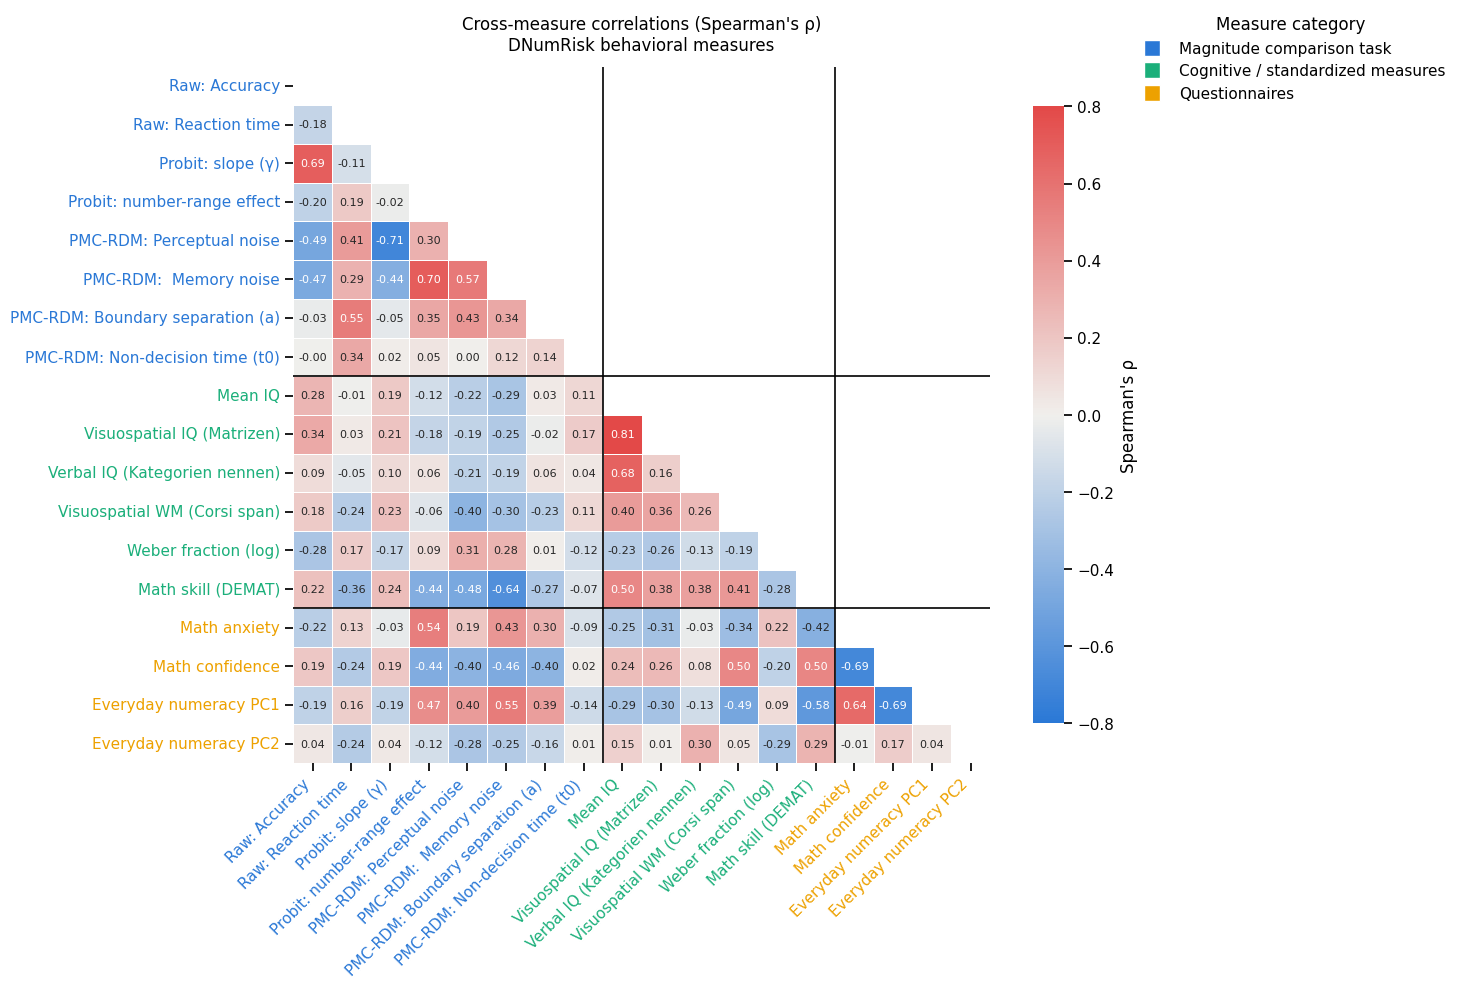

In [4]:
diverging_cmap = LinearSegmentedColormap.from_list('blue_red', ['#2a78d6', '#f0efec', '#e34948'])
mask = np.triu(np.ones_like(corr_sorted, dtype=bool), k=0)  # k=0 also hides the all-1.00 diagonal

fig, ax = plt.subplots(figsize=(0.55 * len(var_order) + 2, 0.55 * len(var_order) + 2))
sns.heatmap(corr_sorted, mask=mask, cmap=diverging_cmap, vmin=-0.8, vmax=0.8, center=0,
            square=True, annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.6, 'label': "Spearman's ρ"}, ax=ax)

style_heatmap_axes(ax)
add_category_legend(fig)

ax.set_title("Cross-measure correlations (Spearman's ρ)\nDNumRisk behavioral measures", pad=12)
plt.tight_layout()
# plt.savefig('/Users/mrenke/data/ds-dnumrisk/plots_and_ims/correlations_across_measures/thesis_cross_measure_heatmap_behavioral.png',
#             dpi=300, bbox_inches='tight')

## Variance explained between measures, group effect removed

Same variable set, but now the partial Spearman correlation between each pair of measures, controlling for group (DD vs. control) — i.e. how much two measures explain of each other's variance *beyond* what both merely share with the group difference. Plotted as r² (0–1, unsigned), since "how much" rather than direction is the question here.

In [5]:
df_partial = df[corr_vars + ['group']].copy()
df_partial['group_numeric'] = (df_partial['group'] == 'dyscalc').astype(int)

partial_r = pd.DataFrame(np.eye(len(corr_vars)), index=corr_vars, columns=corr_vars)
for x_var, y_var in itertools.combinations(corr_vars, 2):
    sub = df_partial[[x_var, y_var, 'group_numeric']].dropna()
    if len(sub) < 10:
        continue
    res = pingouin.partial_corr(data=sub, x=x_var, y=y_var, covar='group_numeric', method='spearman')
    r = res['r'].iloc[0]
    partial_r.loc[x_var, y_var] = partial_r.loc[y_var, x_var] = r

partial_r2 = partial_r ** 2
np.fill_diagonal(partial_r2.values, np.nan)
partial_r2_sorted = partial_r2.loc[var_order, var_order]

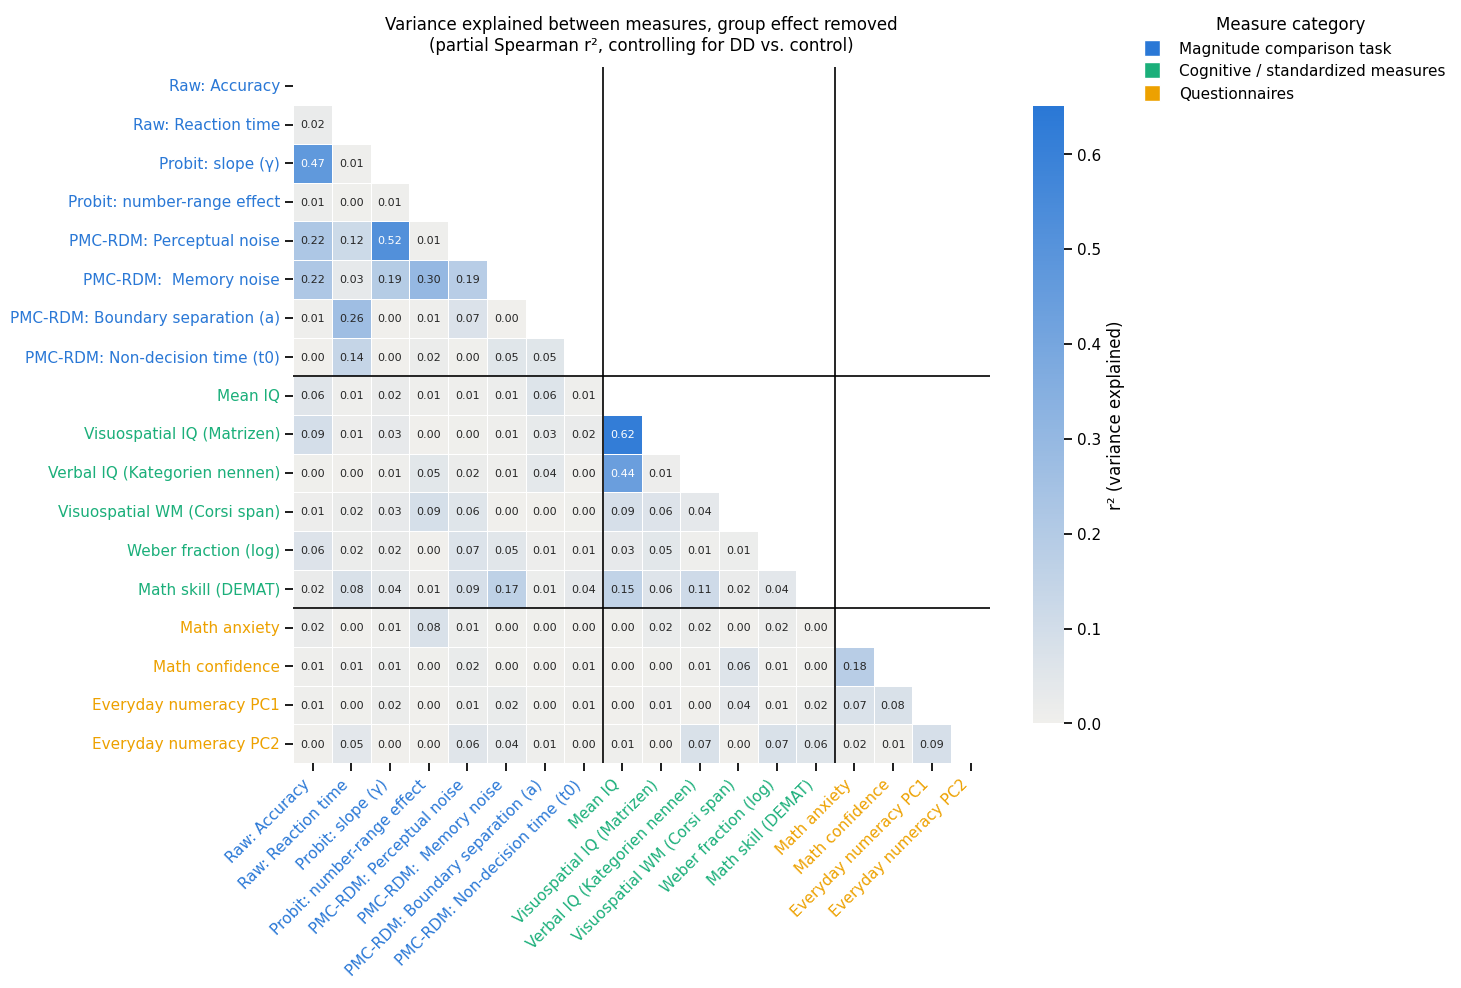

In [6]:
sequential_cmap = LinearSegmentedColormap.from_list('blue_seq', ['#f0efec', '#2a78d6'])
mask_partial = np.triu(np.ones_like(partial_r2_sorted, dtype=bool), k=0)  # diagonal is meaningless here (all-NaN)

fig, ax = plt.subplots(figsize=(0.55 * len(var_order) + 2, 0.55 * len(var_order) + 2))
sns.heatmap(partial_r2_sorted, mask=mask_partial, cmap=sequential_cmap, vmin=0, vmax=0.65,
            square=True, annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.6, 'label': 'r² (variance explained)'}, ax=ax)

style_heatmap_axes(ax)
add_category_legend(fig)

ax.set_title('Variance explained between measures, group effect removed\n(partial Spearman r², controlling for DD vs. control)', pad=12)
plt.tight_layout()
# plt.savefig('/Users/mrenke/data/ds-dnumrisk/plots_and_ims/correlations_across_measures/thesis_cross_measure_partial_r2_group-removed.png',
#             dpi=300, bbox_inches='tight')

## Combine everyday-life PCA plots into one a/b/c panel figure

Combines the three already-exported PDFs (item loadings, mean PC scores per group,
item-level group differences) into a single composite PDF for the thesis appendix,
so only one figure needs to be included there instead of three.

Requires `pymupdf` (`pip install pymupdf`) to rasterize each source PDF page at high
resolution before placing it as a panel — not installed in this environment yet.

saved to /Users/mrenke/obsidian-wiki/thesis/plots/everyday_life_PCA_summary_abc.pdf


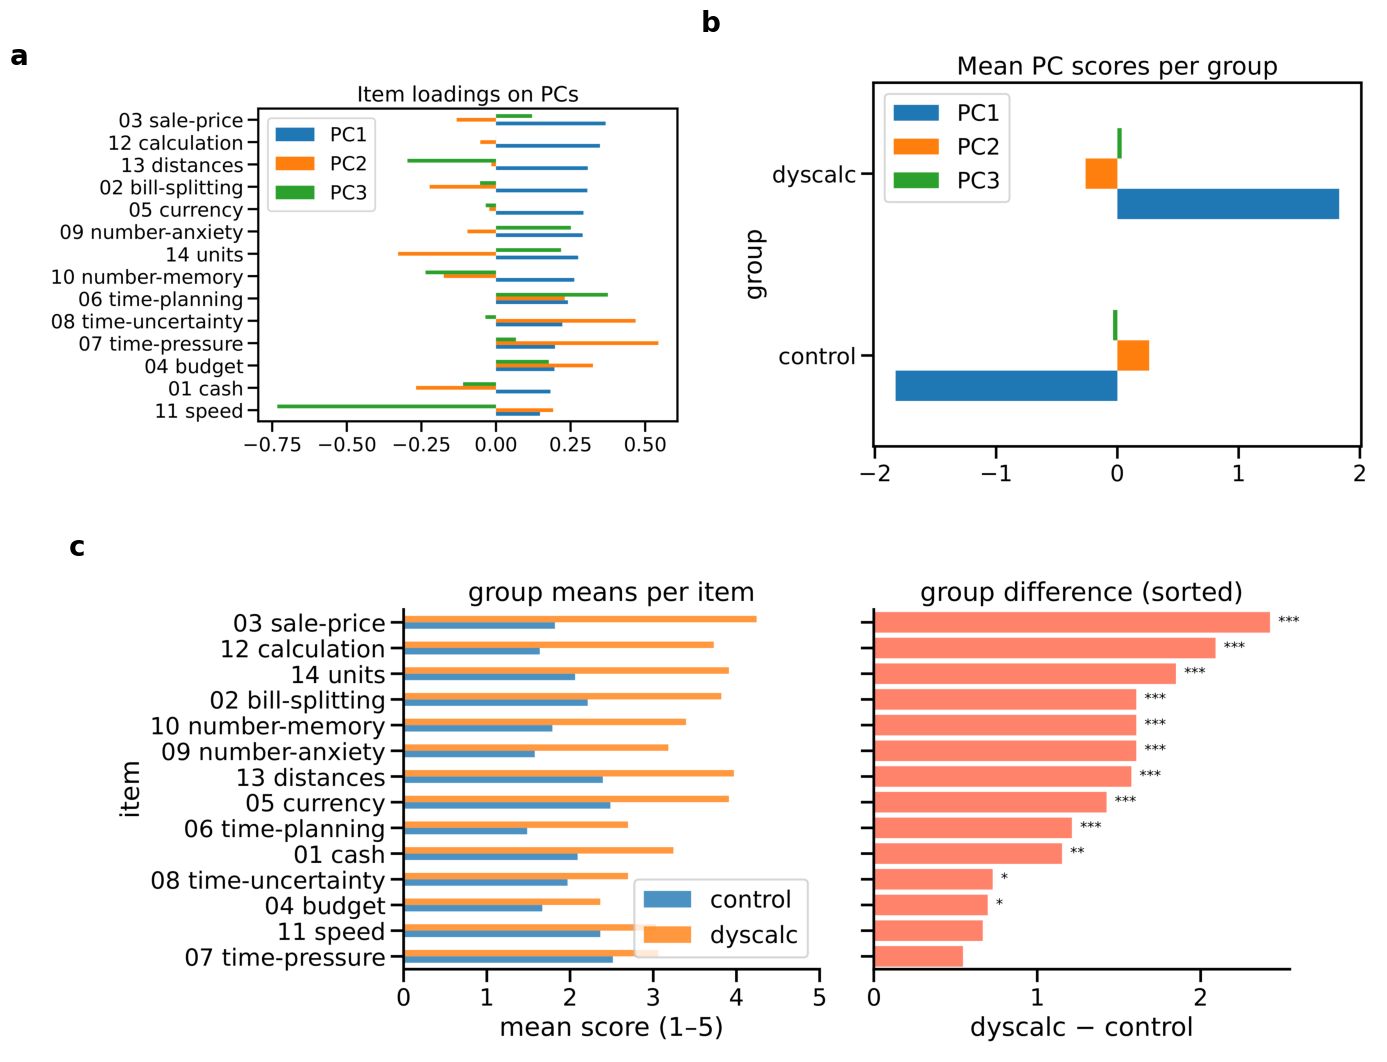

In [2]:
import fitz  # PyMuPDF -- pip install pymupdf
import matplotlib.pyplot as plt
import numpy as np
import os.path as op

plot_folder = '/Users/mrenke/obsidian-wiki/thesis/plots'

panels = {
    'a': op.join(plot_folder, 'everyday_life_item_loadings_PCs.pdf'),
    'b': op.join(plot_folder, 'everyday_life_mean_PC_scores_per_group.pdf'),
    'c': op.join(plot_folder, 'everyday_life_group_differences_per_item.pdf'),
}


def pdf_page_to_array(path, dpi=300):
    """Rasterize the first page of a PDF to an RGB numpy array."""
    doc = fitz.open(path)
    zoom = dpi / 72  # PDF units are points, 72 per inch
    pix = doc[0].get_pixmap(matrix=fitz.Matrix(zoom, zoom), alpha=False)
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
    doc.close()
    return img


def add_panel(ax, label, path):
    ax.imshow(pdf_page_to_array(path))
    ax.axis('off')
    ax.text(-0.02, 1.02, label, transform=ax.transAxes, fontsize=20, fontweight='bold',
             va='bottom', ha='right')


# layout: (a) item loadings and (b) group PC means side by side on top,
# (c) item-level group differences spanning the full width below --
# matches the three plots' native aspect ratios reasonably well
fig, axd = plt.subplot_mosaic(
    [['a', 'b'],
     ['c', 'c']],
    figsize=(14, 11),
    gridspec_kw={'height_ratios': [1, 0.85]},
)

for label, path in panels.items():
    add_panel(axd[label], label, path)

plt.tight_layout()

out_path = op.join(plot_folder, 'everyday_life_PCA_summary_abc.pdf')
plt.savefig(out_path, bbox_inches='tight', dpi=300)
print('saved to', out_path)